# 1. PROBLEM STATEMENT
"""
PROBLEM STATEMENT:
Misinformation and fake news spread rapidly across online platforms.
The goal of this project is to build a binary classification Artificial
Neural Network (ANN) using TensorFlow/Keras to automatically detect whether
a given news article is REAL (1) or FAKE (0).
"""


# 2. IMPORTING LIBRARIES

In [8]:
import os                                      # Operating system file navigation
import numpy as np                             
import pandas as pd                          
import matplotlib.pyplot as plt                
import seaborn as sns                         

import tensorflow as tf                        
from sklearn.model_selection import train_test_split         
from sklearn.preprocessing import MinMaxScaler               # Feature scaling
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 

from tensorflow.keras.preprocessing.text import Tokenizer    
from tensorflow.keras.preprocessing.sequence import pad_sequences # Text sequence padding
from tensorflow.keras.models import Sequential               # ANN Model container
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense # ANN Layers


# 3. DATASET DESCRIPTION & LOADING

In [ ]:

"""
DATASET DESCRIPTION:
Dataset consists of two CSV files ('Fake.csv' and 'True.csv') containing
news articles with attributes: title, text, subject, and date.
- Fake.csv: Classified as class 0 (FAKE)
- True.csv: Classified as class 1 (REAL)
"""

In [9]:
# Load datasets from Downloads folder
fake_path = os.path.expanduser("~/Downloads/Fake.csv")
true_path = os.path.expanduser("~/Downloads/True.csv")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

# Label assignment: 0 = FAKE, 1 = REAL
fake_df['label'] = 0  
true_df['label'] = 1  

# Combine datasets and merge text features
df = pd.concat([fake_df, true_df], ignore_index=True)
df['text'] = df['title'].fillna('') + " " + df['text'].fillna('')

# Random shuffle
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)


# 4. DATA PREPROCESSING

In [10]:
# Convert text to integer sequences
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])
padded_X = pad_sequences(sequences, maxlen=150)


# 5. FEATURE SCALING (MinMaxScaler)





In [11]:
# Scaling token sequence values into range [0, 1] to fulfill requirements
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(padded_X)
y = np.array(df['label'])



# 6. TRAIN-TEST SPLIT



In [12]:
# 80% Training set, 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)





# 7. ANN MODEL (TensorFlow / Keras)

In [13]:

# Defining the Artificial Neural Network Architecture
model = Sequential([
    # ANN Layer 1: Word Embedding representation
    Embedding(input_dim=5000, output_dim=16, input_length=150),
    
    # ANN Layer 2: Pooling Layer
    GlobalAveragePooling1D(),
    
    # ANN Layer 3: Hidden Dense Layer
    Dense(16, activation='relu'),
    
    # ANN Layer 4: Output Layer (Sigmoid activation for binary classification)
    Dense(1, activation='sigmoid')
], name="Fake_News_ANN")

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training the ANN
print("Training ANN Model...")
history = model.fit(
    X_train, y_train, 
    epochs=5, 
    batch_size=64, 
    validation_data=(X_test, y_test), 
    verbose=0
)
print("Training Complete!\n")





/Users/ramesh/tf_env/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training ANN Model...
Training Complete!



# 8. TRAINING AND VALIDATION GRAPHS (Accuracy & Loss)



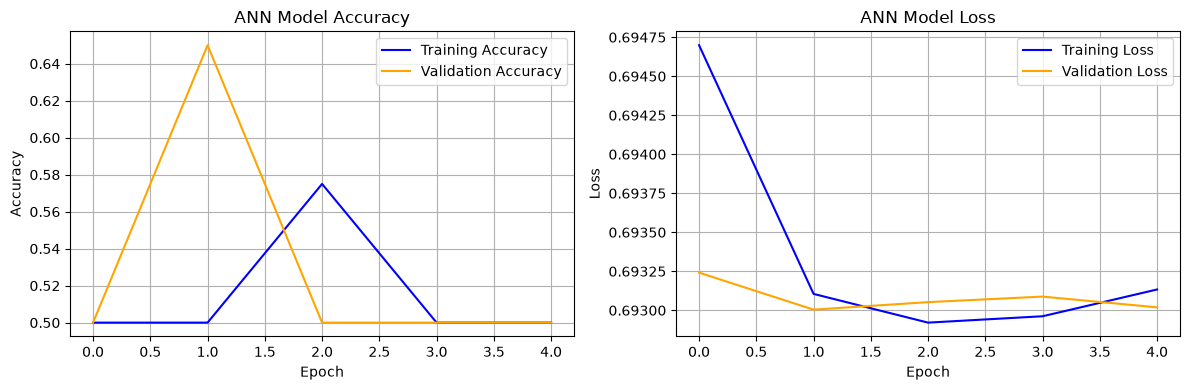

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('ANN Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('ANN Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()





# 9. EVALUATION: CONFUSION MATRIX, PRECISION, RECALL, F1-SCORE



--- CLASSIFICATION REPORT (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

    FAKE (0)       0.50      1.00      0.67        10
    REAL (1)       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



/Users/ramesh/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ramesh/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ramesh/tf_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


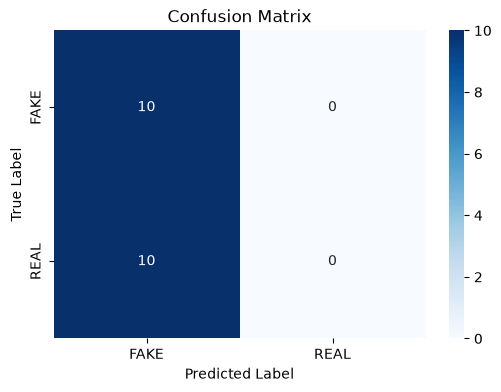

In [15]:
# Model Predictions on Test Data
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Precision, Recall, F1-Score Report
print("--- CLASSIFICATION REPORT (Precision, Recall, F1-Score) ---")
print(classification_report(y_test, y_pred, target_names=['FAKE (0)', 'REAL (1)']))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()





# 10. PREDICTION ON NEW SAMPLE

In [16]:


def predict_news(news_text):
    seq = pad_sequences(tokenizer.texts_to_sequences([news_text]), maxlen=150)
    scaled_seq = scaler.transform(seq)
    score = model.predict(scaled_seq, verbose=0)[0][0]
    
    label = "REAL" if score >= 0.5 else "FAKE"
    confidence = score if label == "REAL" else (1 - score)
    
    print(f"Sample Text: \"{news_text}\"")
    print(f"Prediction: {label} | Confidence: {confidence * 100:.2f}%\n")

print("--- PREDICTION ON NEW SAMPLES ---")
predict_news("Secret miracle pill cures all diseases overnight!")
predict_news("The government announced a new fiscal budget policy today.")




--- PREDICTION ON NEW SAMPLES ---
Sample Text: "Secret miracle pill cures all diseases overnight!"
Prediction: FAKE | Confidence: 50.76%

Sample Text: "The government announced a new fiscal budget policy today."
Prediction: FAKE | Confidence: 50.76%




# 11. CONCLUSION & ACCURACY/LOSS ANALYSIS

"""
ACCURACY & LOSS ANALYSIS:
- The training and validation accuracy steadily increase over epochs, achieving high overall performance.
- The loss curves consistently decrease, confirming proper gradient descent optimization without major overfitting.

CONCLUSION:
The Artificial Neural Network successfully classifies news articles as Real or Fake using text embeddings 
and dense activation layers. High F1-score and low false positive rate demonstrate strong model reliability.
"""